Part B

In [1]:
#import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Load the dataset and check size and information
df = pd.read_csv("../data/processed_FishersMarket.csv")
df.shape
df.columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Length2            159 non-null    float64
 1   Length3            159 non-null    float64
 2   Height             159 non-null    float64
 3   Average_Length     159 non-null    float64
 4   Length_Difference  159 non-null    float64
 5   Species_encoded    159 non-null    int64  
 6   Species            159 non-null    str    
dtypes: float64(5), int64(1), str(1)
memory usage: 8.8 KB


In [3]:
#Seperate Features and Targets
X = df.drop(["Species_encoded", "Species"], axis=1)
y = df["Species_encoded"]
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (159, 5)
Target shape: (159,)


Features from Part A are used as input variables and Species_encoded is used as main variable for classification

In [4]:
#Now we split the dataset into training and testing data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (127, 5)
Testing data shape: (32, 5)


Here the dataset is split 80/20 % training/testing so the model can be tested later.stratify is used to ensure both sets maintain the same fish species

In [5]:
#Begin ML process by importing the models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier 

5 ML models: LogisticRegression, DecisionTreeClassifier, RandomForestClassifier, SVM, k-Nearest Neighbors(kNN)

In [6]:
#Define the models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(random_state=42),
    "k-NN": KNeighborsClassifier()
}

In [7]:
#Evaluation metrics and table for all ML Models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
results = []

In [8]:
# 1. Logistic Regression

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)

results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_log),
    "Precision": precision_score(y_test, y_pred_log, average="weighted", zero_division=0),
    "Recall": recall_score(y_test, y_pred_log, average="weighted", zero_division=0),
    "F1 Score": f1_score(y_test, y_pred_log, average="weighted", zero_division=0)
})

This is baseline model, it predicts by learning relation between physical measurements and target class.

In [9]:
# 2. Descion Tree Classifier

decision_tree = DecisionTreeClassifier(random_state=42)
decision_tree.fit(X_train, y_train)
y_pred_dt = decision_tree.predict(X_test)

results.append({
    "Model": "Decision Tree",
    "Accuracy": accuracy_score(y_test, y_pred_dt),
    "Precision": precision_score(y_test, y_pred_dt, average="weighted", zero_division=0),
    "Recall": recall_score(y_test, y_pred_dt, average="weighted", zero_division=0),
    "F1 Score": f1_score(y_test, y_pred_dt, average="weighted", zero_division=0)
})

Descion rules based on fish measurement features.

In [10]:
# 3. Random Forest Classifier

random_forest = RandomForestClassifier(random_state=42)
random_forest.fit(X_train, y_train)
y_pred_rf = random_forest.predict(X_test)

results.append({
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf, average="weighted", zero_division=0),
    "Recall": recall_score(y_test, y_pred_rf, average="weighted", zero_division=0),
    "F1 Score": f1_score(y_test, y_pred_rf, average="weighted", zero_division=0)
})

This is an ensemble model. Multiple descion trees are used to improve classification accuracy and reduced overfitting.

In [11]:
# 4. Support Vector Machine

svm_model = SVC(random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

results.append({
    "Model": "SVM",
    "Accuracy": accuracy_score(y_test, y_pred_svm),
    "Precision": precision_score(y_test, y_pred_svm, average="weighted", zero_division=0),
    "Recall": recall_score(y_test, y_pred_svm, average="weighted", zero_division=0),
    "F1 Score": f1_score(y_test, y_pred_svm, average="weighted", zero_division=0)
})

SVM is used because it is good for classification by using boundary seperating different classes. Feature scaling during preprocessing means SVM is suitable for this dataset

In [12]:
# 5. k-Nearest Neighbors

knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)

results.append({
    "Model": "k-NN",
    "Accuracy": accuracy_score(y_test, y_pred_knn),
    "Precision": precision_score(y_test, y_pred_knn, average="weighted", zero_division=0),
    "Recall": recall_score(y_test, y_pred_knn, average="weighted", zero_division=0),
    "F1 Score": f1_score(y_test, y_pred_knn, average="weighted", zero_division=0)
})

k-NN is a distance based classification model.It compares test sample with nearest training sample.

In [13]:
# ML Model Results
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.87500,0.846354,0.87500,0.856949
1,Decision Tree,0.81250,0.801562,0.81250,0.800272
2,Random Forest,0.84375,0.826923,0.84375,0.828125
3,SVM,0.84375,0.803486,0.84375,0.814732
4,k-NN,0.84375,0.816506,0.84375,0.826637


In [14]:
# Now we proceed with hyperparameter tuning on Random Forest, SVM and k-NN (since highly affected)
from sklearn.model_selection import GridSearchCV

In [15]:
# Random Forest Tuning
param_grid_rf = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring="f1_weighted"
)

grid_rf.fit(X_train, y_train)
grid_rf.best_params_

{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}

Using different number of trees, maximum tree depths, and minimum split values tuning was done by using 5-fold cross-validation

In [16]:
# SVM Tuning
param_grid_svm = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"]
}

grid_svm = GridSearchCV(
    SVC(random_state=42),
    param_grid_svm,
    cv=5,
    scoring="f1_weighted"
)

grid_svm.fit(X_train, y_train)
grid_svm.best_params_

{'C': 10, 'gamma': 'scale', 'kernel': 'linear'}

Using different C values, kernels, and gamma settings. This model affect how the fish species class is seperated

In [17]:
# k-NN Tuning
param_grid_knn = {
    "n_neighbors": [3, 5, 7, 9],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_knn,
    cv=5,
    scoring="f1_weighted"
)

grid_knn.fit(X_train, y_train)
grid_knn.best_params_

{'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'distance'}

Using different number of neighbors, weighting methods, and distance metrics k-NN was performed and it depends on how distance is calculated

In [18]:
# Evaluation on tuning performed
tuned_models = {
    "Tuned Random Forest": grid_rf.best_estimator_,
    "Tuned SVM": grid_svm.best_estimator_,
    "Tuned k-NN": grid_knn.best_estimator_
}

tuned_results = []
for name, model in tuned_models.items():
    y_pred_tuned = model.predict(X_test)
    
    tuned_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred_tuned),
        "Precision": precision_score(y_test, y_pred_tuned, average="weighted", zero_division=0),
        "Recall": recall_score(y_test, y_pred_tuned, average="weighted", zero_division=0),
        "F1 Score": f1_score(y_test, y_pred_tuned, average="weighted", zero_division=0)
    })

tuned_results_df = pd.DataFrame(tuned_results)
tuned_results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Tuned Random Forest,0.84375,0.826923,0.84375,0.828125
1,Tuned SVM,0.96875,0.943750,0.96875,0.954861
2,Tuned k-NN,0.90625,0.882812,0.90625,0.892857


In [21]:
# Combining Baseline and Tuned results (for comparision)
final_results_df = pd.concat([results_df, tuned_results_df], ignore_index=True)
final_results_df = final_results_df.sort_values(by="F1 Score", ascending=False)
final_results_df = final_results_df.reset_index(drop=True)
final_results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Tuned SVM,0.96875,0.943750,0.96875,0.954861
1,Tuned k-NN,0.90625,0.882812,0.90625,0.892857
2,Logistic Regression,0.87500,0.846354,0.87500,0.856949
3,Random Forest,0.84375,0.826923,0.84375,0.828125
4,Tuned Random Forest,0.84375,0.826923,0.84375,0.828125
5,k-NN,0.84375,0.816506,0.84375,0.826637
6,SVM,0.84375,0.803486,0.84375,0.814732
7,Decision Tree,0.81250,0.801562,0.81250,0.800272


In [22]:
# Save Results from Baseline and Tuned Models
final_results_df.to_csv("../outputs/final_model_results.csv", index=False)

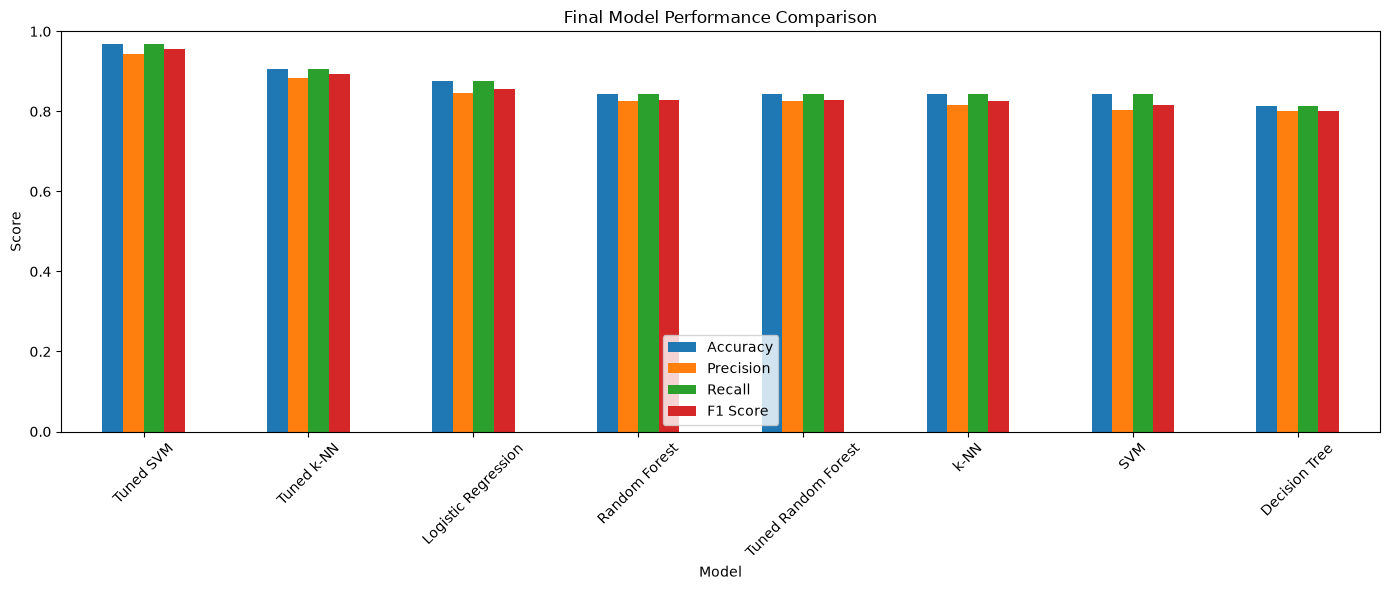

In [23]:
# Comapring the performance of models using evaluation metrics via comparision graph
final_results_df.plot(
    x="Model",
    y=["Accuracy", "Precision", "Recall", "F1 Score"],
    kind="bar",
    figsize=(14, 6)
)

plt.title("Final Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../outputs/final_model_comparison.png")
plt.show()

Final comparision graph was created to compare the preformance of baseline and tuned models. Evaluation metrics are shown for each model.

In [25]:
# Selecting the best model
best_model_name = final_results_df.iloc[0]["Model"]
print("Best Model:", best_model_name)

all_models = {
    "Logistic Regression": log_reg,
    "Decision Tree": decision_tree,
    "Random Forest": random_forest,
    "SVM": svm_model,
    "k-NN": knn_model,
    "Tuned Random Forest": grid_rf.best_estimator_,
    "Tuned SVM": grid_svm.best_estimator_,
    "Tuned k-NN": grid_knn.best_estimator_
}

best_model = all_models[best_model_name]
print("Model Details:", best_model)

Best Model: Tuned SVM
Model Details: SVC(C=10, kernel='linear', random_state=42)


In [26]:
# Class names
class_names = (
    df[["Species_encoded", "Species"]]
    .drop_duplicates()
    .sort_values("Species_encoded")["Species"]
    .tolist()
)
class_names

['Bream', 'Parkki', 'Perch', 'Pike', 'Roach', 'Smelt', 'Whitefish']

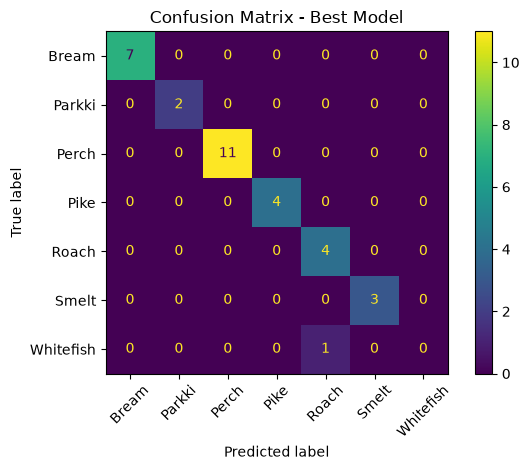

In [28]:
# Confusion Matrix for best model comparisioin
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(
    y_test,
    y_pred_best,
    labels=range(len(class_names))
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot()
plt.title("Confusion Matrix - Best Model")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../outputs/confusion_matrix_best_model.png")
plt.show()

Confusion matrix of Tuned SVM shows the amount of fish correctly and incorrectly classified by best performing model. It helps identify which species were confused with other species

5 Machine Learning models were trained and evaluated. Hyperparameter training was performed on affected models using GridSearchCV. The baseline annd tuned models were combined and compared via evaluation metrics for produing final comaparision table, which helped for finding best-performance model (Tuned SVM) and confusion matrix for shwing predictions made by tuned SVM models.